# MCP(Model Context Protocol) 핵심 개념

MCP는 AI 애플리케이션이 외부 도구와 데이터를 **같은 연결 규칙**으로 발견하고 사용하는 공개 프로토콜이다. Server가 기능 계약을 공개하고 Client가 그 계약을 읽기 때문에, Host마다 파일·문서·업무 API 연결 방식을 새로 만들 필요가 줄어든다.

이 실습에서 기준으로 삼는 Host는 **PyCharm의 JetBrains AI Assistant**이다. AI Assistant 내부의 MCP Client가 Filesystem·Context7 같은 Server와 통신하는 구조를 기준으로 역할과 요청 흐름을 익힌다.


## MCP가 등장한 이유

MCP 이전에는 AI 애플리케이션과 외부 시스템의 조합마다 별도 connector를 만드는 경우가 많았다.

AI 애플리케이션이 `N`개이고 외부 시스템이 `M`개라면 최대 `N × M`개의 연결 코드를 관리해야 하며, 인증·오류·schema 처리 방식도 connector마다 달라질 수 있다.

MCP는 AI 애플리케이션 쪽에 공통 Client 규칙을, 기능 제공 쪽에 공통 Server 규칙을 둔다. Server가 Tool·Resource·Prompt 계약을 한 번 공개하면 서로 다른 Host가 같은 발견·요청 방식을 재사용할 수 있다.

흔히 **AI 애플리케이션을 위한 USB-C**에 비유하지만, 연결 규격이 같다고 해서 권한과 안전성까지 자동으로 보장되지는 않는다.

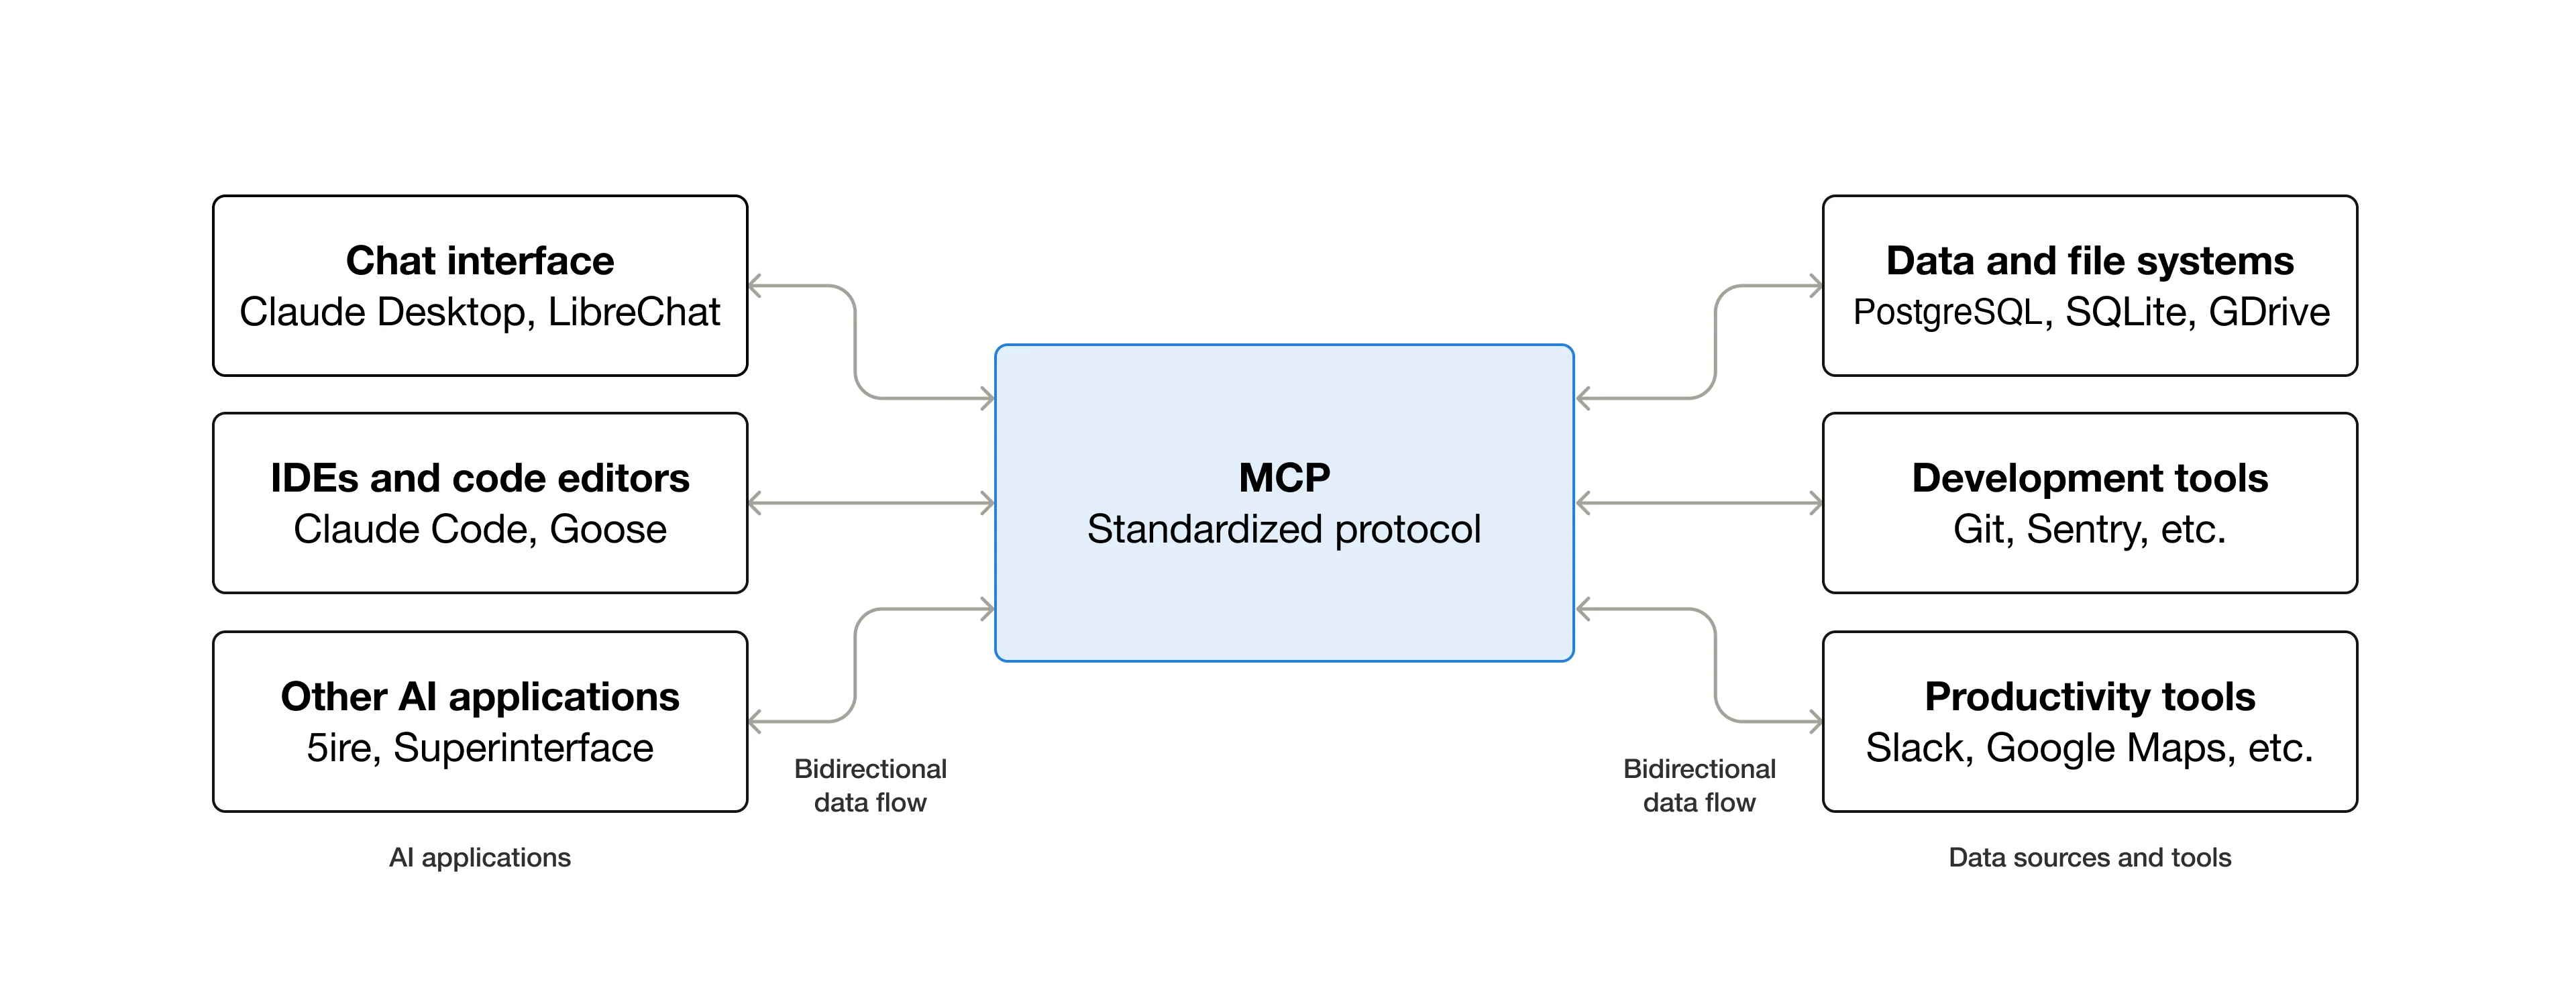

> 출처: [Model Context Protocol 공식 입문 문서](https://modelcontextprotocol.io/docs/2026-07-28/getting-started/intro)


## MCP가 담당하지 않는 것

MCP를 LLM이나 Agent 자체로 이해하면 역할 경계가 흐려진다. MCP는 아래 기능을 대신 만드는 기술이 아니라, 외부 기능을 **발견하고 요청하고 응답받는 연결 계약**이다.

| 구분 | 담당하는 일 | MCP와의 관계 |
|---|---|---|
| LLM | 자연어 이해와 응답 생성 | 사용할 Tool을 판단할 수 있지만 MCP 자체와는 구분된다. |
| Agent | 목표에 따라 다음 행동과 반복을 결정 | MCP Server의 기능을 행동 수단으로 사용할 수 있다. |
| API·DB·파일 | 실제 업무 기능과 데이터 제공 | MCP Server 내부에서 접근하는 대상이 된다. |
| RAG | 검색 문서를 모델 문맥으로 만드는 패턴 | Retriever를 Tool이나 Resource로 공개할 수 있지만 MCP는 RAG 알고리즘이 아니다. |

따라서 모델이 Server에 직접 접속한다고 표현하지 않는다. Host가 모델·권한·사용자 경험을 관리하고, 내부 Client가 MCP 메시지를 Server에 전달한다.


## MCP를 구성하는 Host·Client·Server

**Host**는 사용자가 실행하는 AI 애플리케이션이며 모델·대화·권한·승인을 관리한다. 이 실습에서는 PyCharm의 JetBrains AI Assistant가 Host이다.

Host 안의 **Client**는 특정 Server와 연결하고 기능 발견·요청 전달을 담당한다. 한 Host가 여러 Server를 사용하면 Server별 Client 연결도 각각 존재한다.

**Server**는 Tool·Resource·Prompt의 이름과 schema를 공개하고 실제 기능을 수행한다. Filesystem Server는 허용된 로컬 폴더를 다루고, Context7 Server는 외부 문서 검색 기능을 제공한다.

```mermaid
flowchart LR
    U["사용자"] --> H
    subgraph H["Host · PyCharm JetBrains AI Assistant"]
        APP["모델 · 대화 · 권한 · 승인"]
        C1["MCP Client A"]
        C2["MCP Client B"]
        APP --> C1
        APP --> C2
    end
    C1 <-->|"MCP 연결"| S1["Filesystem Server"]
    C2 <-->|"MCP 연결"| S2["Context7 Server"]
    S1 -.-> D1["허용된 로컬 폴더"]
    S2 -.-> D2["외부 라이브러리 문서"]
```

위 그림은 `사용자 → Host → Client → Server → 실제 대상` 순서로 읽는다. 같은 PyCharm 안에서도 AI Assistant는 Host이고, Server별 통신 모듈이 Client이며, 파일이나 문서를 실제로 제공하는 프로그램이 Server이다.

> 출처: [MCP Architecture](https://modelcontextprotocol.io/specification/2026-07-28/architecture)를 실습 흐름에 맞게 단순화하였다.


## Server가 제공하는 세 가지 기능

MCP의 **primitive**는 Client가 발견하고 사용할 수 있도록 Server가 공개하는 기본 기능 단위이다. 세 종류는 반환하는 것과 주로 선택하는 주체가 다르다.

| Primitive | 제공하는 것 | 주로 선택하는 주체 | 대표 method |
|---|---|---|---|
| **Tools** | 계산·검색·변경 같은 실행 결과 | 모델 | `tools/list`, `tools/call` |
| **Resources** | URI로 식별되는 읽기용 문맥 데이터 | 애플리케이션 | `resources/list`, `resources/read` |
| **Prompts** | 재사용할 메시지·지시 템플릿 | 사용자 | `prompts/list`, `prompts/get` |

Tools가 *model-controlled*라는 표현은 모델에 무조건 실행 권한이 있다는 뜻이 아니다. Host는 삭제·결제·게시처럼 부작용이 큰 호출에 승인과 권한 정책을 적용할 수 있다.

세 기능의 경계를 먼저 구분하고, 이후 Math Tool 실습에서 목록 조회와 호출을 확인한다.


## discovery와 call은 서로 다른 단계이다

최신 stateless core의 MCP 요청은 **transport 연결을 준비하는 단계**, **사용할 Tool 목록을 조회하는 단계**, **Host가 선택·승인한 Tool을 호출하는 단계**로 나뉜다. 발견은 메뉴와 입력 규칙을 읽는 일이고, 호출은 실제 함수나 외부 작업을 실행하는 일이다.

```mermaid
sequenceDiagram
    participant H as Host
    participant C as MCP Client
    participant S as MCP Server

    Note over C,S: 1. Transport 연결 준비 · 필수 protocol session 없음

    Note over C,S: 2. Tool 목록 조회
    C->>S: tools/list
    S-->>C: name · description · input schema

    Note over H,S: 3. Tool 선택과 실행
    H->>C: 선택한 Tool 이름 · 승인된 arguments
    C->>S: tools/call
    S->>S: schema 검증 후 실제 기능 실행

    Note over H,S: 4. 결과 전달
    S-->>C: result 또는 error
    C-->>H: 구조화된 결과
```

### 다이어그램 읽는 방법

1. STDIO subprocess 또는 Streamable HTTP endpoint와 transport 연결을 준비한다. 이때 필수 protocol session이나 `initialize` handshake는 없다.
2. `tools/list`는 Tool의 이름·설명·입력 schema를 가져오며 Tool을 실행하지 않는다.
3. Host가 Tool과 arguments를 선택·승인하면 Client가 `tools/call`을 보내고 Server가 실제 기능을 실행한다.
4. Server의 result 또는 error가 Client를 거쳐 Host로 돌아온다.

따라서 입문 기본 흐름은 `transport 연결 준비(필수 protocol session/initialize 없음) → tools/list → Host 선택·승인 → tools/call → result`이다. 필수 `initialize`·`initialized` handshake는 modern stateless core에서 제거되었다. 다만 legacy Server나 일부 SDK가 이전 revision과의 호환성을 협상할 때는 `initialize` 계열 메시지를 사용할 수 있으므로 이를 최신 기본 단계로 일반화하지 않는다. `server/discover`는 Server가 구현해야 하고 Client는 필요할 때 호출할 수 있는 지원 version·capability 확인용 선택 method이며, 기본 실습에서는 SDK에 맡긴다.

핵심은 **발견 성공과 실행 성공은 다르다**는 점이다. Tool이 목록에 보여도 Server 상태·권한·입력값 문제로 실제 호출은 실패할 수 있다.


## 공식 transport는 STDIO와 Streamable HTTP이다

Transport는 같은 MCP 메시지를 **어디로 어떻게 운반하는가**를 정한다. 이 실습에서 구분할 공식 transport는 두 가지이다.

| 공식 transport | Server 시작과 연결 | 실습 예시 |
|---|---|---|
| **STDIO** | Host가 로컬 Server subprocess를 시작하고 표준 입출력으로 통신한다. | Filesystem Server |
| **Streamable HTTP** | Client가 실행 중인 `/mcp` endpoint에 HTTP 요청을 보낸다. | Context7과 직접 만든 HTTP Server |

**Remote HTTPS**는 별도의 세 번째 transport가 아니다. 원격 배포된 Streamable HTTP endpoint를 TLS가 적용된 HTTPS로 호출하는 운영 형태이다.

**in-memory 연결**도 MCP의 공식 transport가 아니다. 같은 Python 프로세스 안에서 Server 객체를 직접 연결하는 SDK 테스트 편의 기능이며, 별도 프로세스·포트·IDE Host 실습을 대신하지 않는다.

STDIO Server의 stdout은 protocol 메시지용으로 유지하고, 원격 Streamable HTTP 배포에는 인증·TLS·timeout 같은 운영 보호 장치를 추가한다.


## 최신 MCP의 핵심 변화

다음 네 가지 핵심 변화를 기억한다.

1. **Protocol revision과 SDK version은 다르다.** `2026-07-28`은 통신 규칙의 개정일이고 `mcp` 2.x는 그 규칙을 Python으로 구현한 패키지 버전이다.
2. **최신 core는 stateless이다.** 필수 protocol session과 `initialize`·`initialized` handshake가 제거되어 요청이 이전 연결 상태에 의존하지 않는다.
3. **Python SDK v2의 고수준 Server class는 `MCPServer`이다.** 이전 자료의 `FastMCP` import와 별도 `fastmcp` package를 현재 실습 코드에 섞지 않는다.
4. **공식 transport는 STDIO와 Streamable HTTP이다.** 기존 HTTP+SSE 방식은 legacy 경로이고, 이 실습은 사용하지 않는다.

Stateless 구조에서는 요청이 특정 연결이나 특정 replica에 고정되지 않으므로, 같은 MCP Server 애플리케이션의 여러 replica로 요청을 분산하기 쉬워진다.

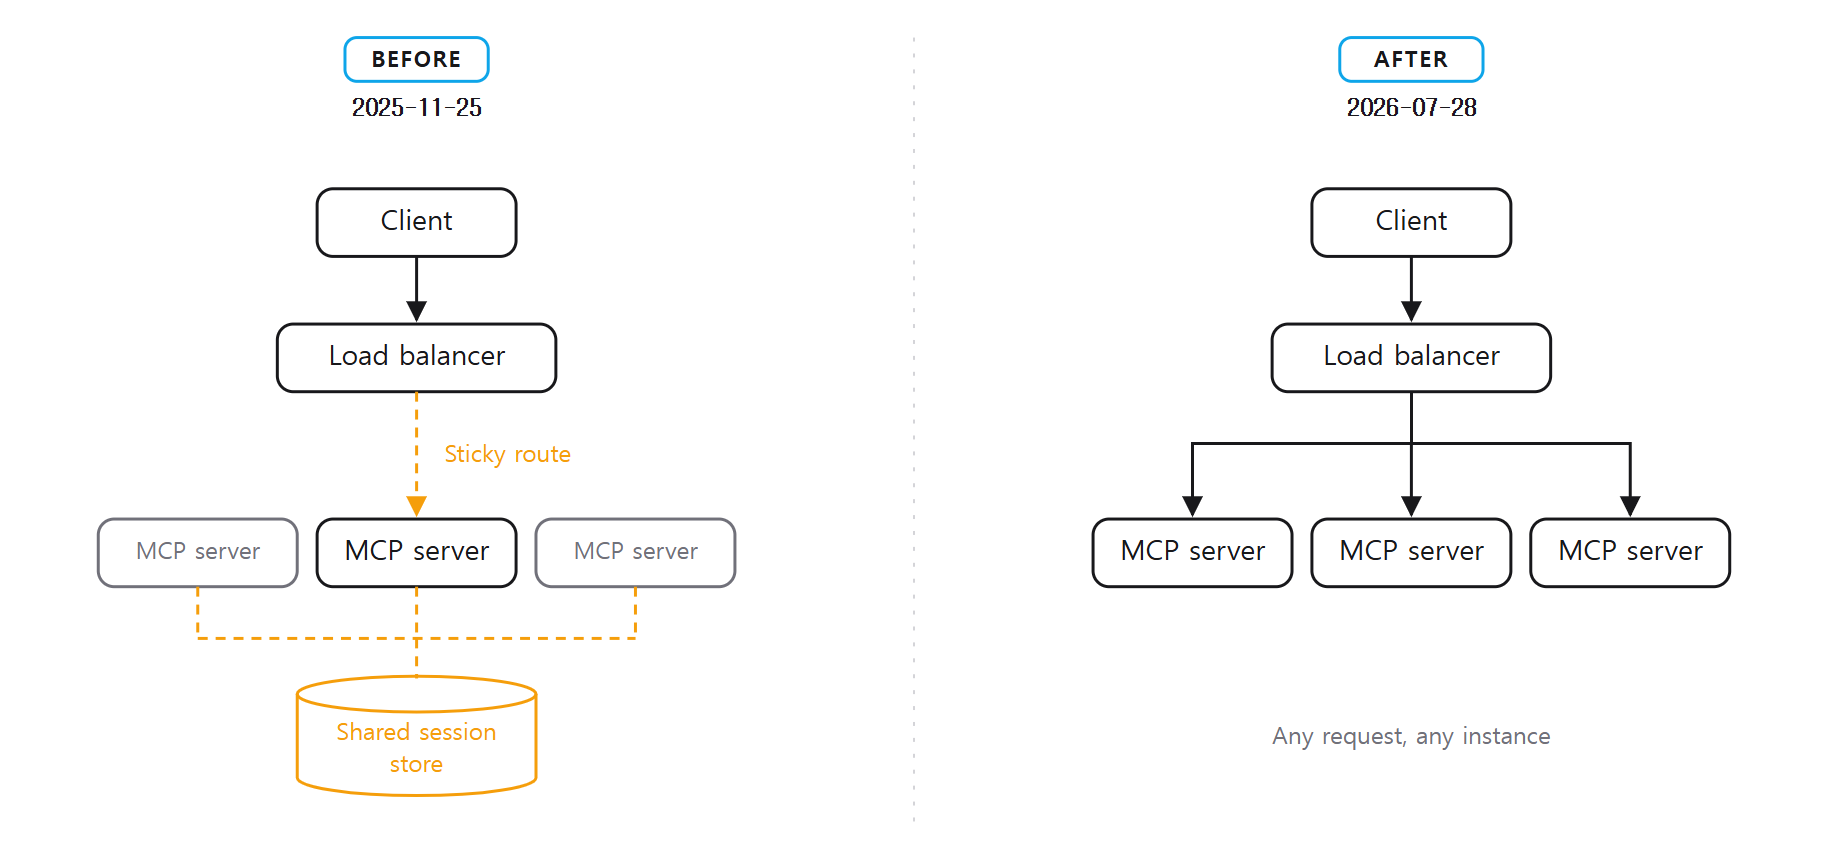


왼쪽의 Server 세 개와 오른쪽의 Server 세 개는 서로 다른 기능의 Server가 아니라, **같은 MCP 서비스 코드를 여러 개 실행한 replica**이다. 이전 구조는 같은 세션을 특정 replica로 보내는 sticky route와 공유 세션 저장소에 의존했다. 최신 구조는 같은 서비스의 어느 replica가 요청을 받아도 처리할 수 있는 방향을 나타낸다.

stateless는 Server가 업무 데이터나 인증 정보를 절대 저장할 수 없다는 뜻이 아니다. MCP 요청 처리가 이전 연결의 세션 상태에 의존하지 않는다는 뜻이다.

`MRTR`, `ttlMs`, discovery cache와 관련 response header는 캐시 재검증·운영 최적화에 관한 고급 참고 키워드이다. 기초 실습에서는 구현하거나 값을 조정하지 않으며, 최신 revision에 이런 운영 세부사항이 있다는 정도만 확인한다.


## MCP를 안전하게 사용하려면

MCP는 표준 연결을 제공하지만 Server를 자동으로 신뢰하거나 안전하게 만들지는 않는다.

- 출처와 코드를 확인하지 않은 로컬 Server를 실행하지 않는다.
- Server에는 필요한 파일·DB·API 범위만 허용하고 비밀값은 모델 메시지에 넣지 않는다.
- 삭제·결제·게시처럼 되돌리기 어려운 Tool은 실행 전에 사용자 승인을 받는다.
- Tool arguments와 result, Resource 본문을 신뢰하지 않고 schema와 업무 규칙으로 검증한다.
- 원격 Server에는 TLS·인증·timeout·rate limit·감사 로그를 적용한다.

발견된 Tool 수와 실제 실행 권한은 별개의 값이다. Host는 사용자와 정책에 따라 노출 목록과 실행 가능 범위를 더 좁힐 수 있다.


## 정리

MCP는 Agent나 LLM 자체가 아니라 AI 애플리케이션과 외부 기능 사이의 표준 연결 계약이다. 역할을 헷갈릴 때는 다음 네 문장으로 확인한다.

1. PyCharm의 JetBrains AI Assistant는 모델·대화·권한을 관리하는 **Host**이다.
2. AI Assistant 내부의 **Client**는 특정 Server와 연결·발견·호출 메시지를 주고받는다.
3. Filesystem·Context7 같은 **Server**는 기능 계약과 실제 결과를 제공한다.
4. `tools/list`는 발견이고 `tools/call`은 실행이며, 둘의 성공 여부는 서로 다르다.
